In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector as mc

In [41]:
# Connect To Python To MySQL :

#!pip install mysql-connector-python

conn = mc.connect(
    host = '127.0.0.1',
    port = '3306',
    user = 'root',
    password = '1234',
    database = 'productivity_tracker'
)

cur = conn.cursor()
cur.execute("SELECT * FROM tasks_logs")
data = cur.fetchall()

In [42]:
ndf = pd.DataFrame(data, columns=['t_id','t_date','task','t_status'])

ndf['t_status'] = ndf['t_status'].astype(int)
ndf['t_date'] = pd.to_datetime(ndf['t_date']).dt.date

In [43]:
dates = ndf['t_date'].unique()
for d in dates:
    day_df = ndf[ndf['t_date'] == d]
    total = len(day_df)
    complete = len(day_df[day_df['t_status'] == 1])
    incomplete = total - complete
    percentage = (complete/total)*100

    print(f'\nDate: {d}')
    print(total, complete)
    print(f"Completion %: {percentage:.2f}")


Date: 2026-03-22
10 1
Completion %: 10.00

Date: 2026-03-23
10 7
Completion %: 70.00

Date: 2026-03-24
10 5
Completion %: 50.00

Date: 2026-03-25
10 3
Completion %: 30.00

Date: 2026-03-26
10 4
Completion %: 40.00

Date: 2026-03-27
10 8
Completion %: 80.00

Date: 2026-03-28
10 3
Completion %: 30.00


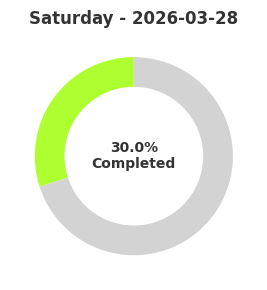

In [44]:
plt.figure(figsize=(6,3))
plt.pie([complete, incomplete],
        startangle=90,
        colors=['greenyellow', 'lightgrey'])
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.text(0, 0, f'{percentage:.1f}%\nCompleted',
         ha='center', va='center', fontsize=10, fontweight='bold', color='black', alpha=0.8)

plt.title(f'Saturday - {d}', fontsize=12, fontweight='bold', color='black', alpha=0.8)
plt.tight_layout()
plt.show()

#### Day-Wise Habit

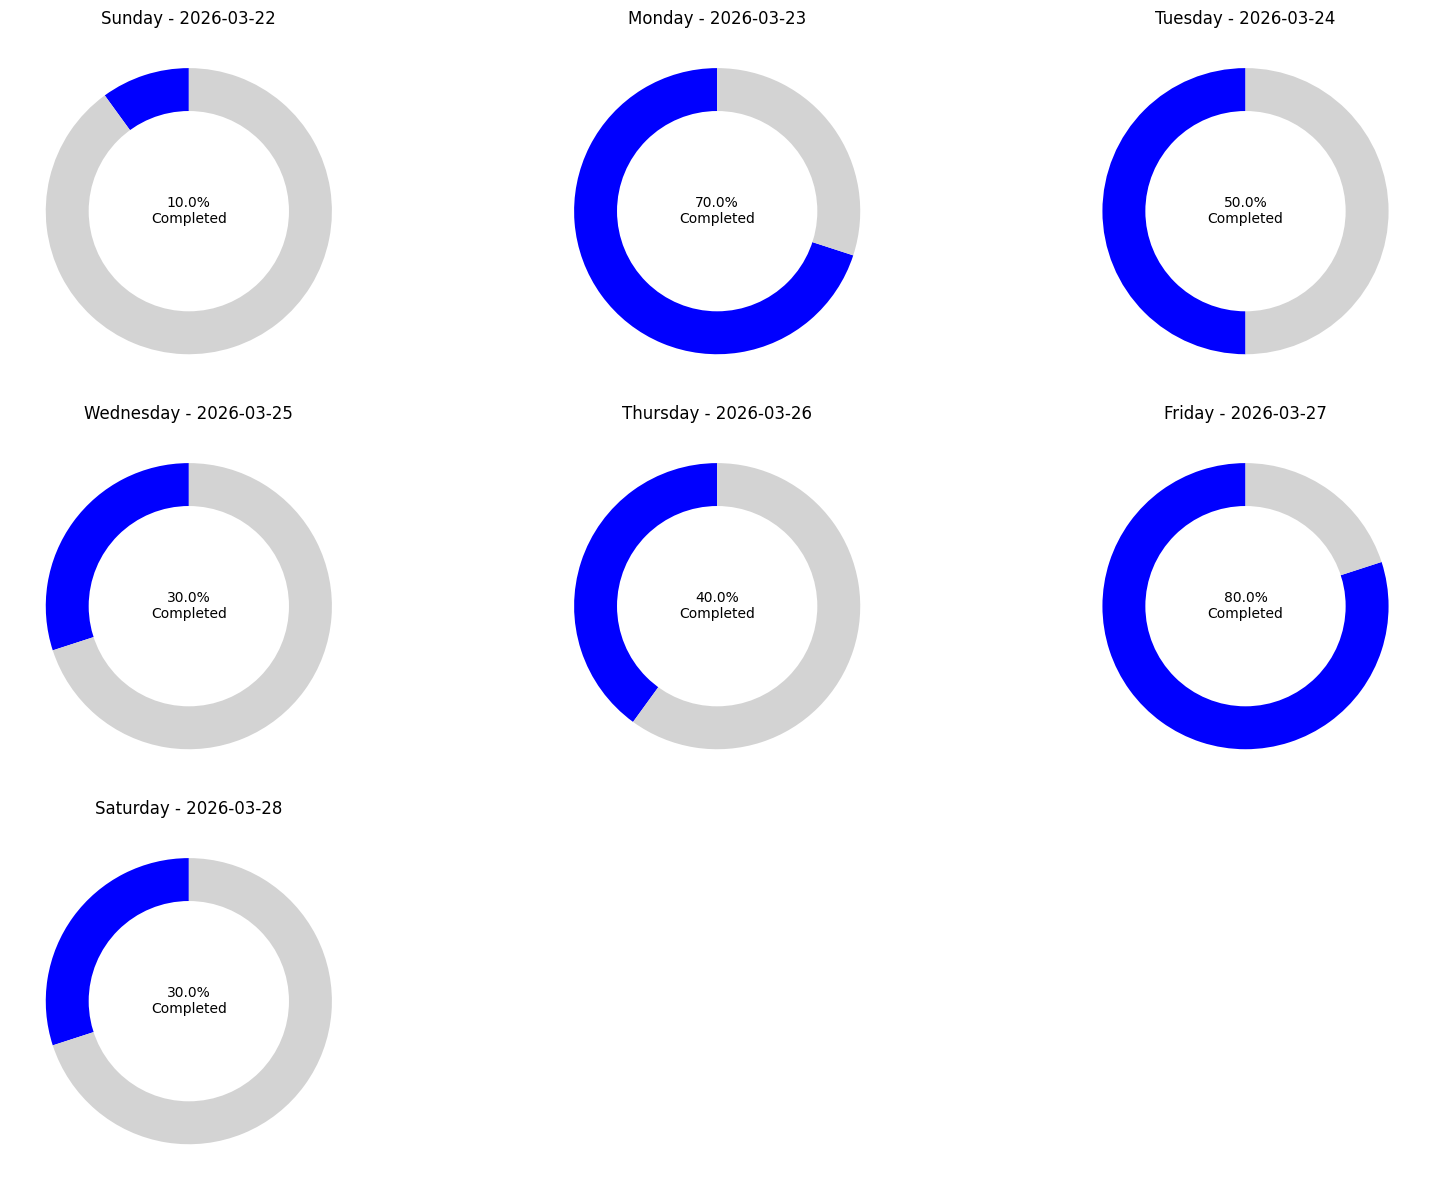

In [45]:
import math
from datetime import datetime

dt = ['2026-03-22','2026-03-23','2026-03-24','2026-03-25','2026-03-26','2026-03-27','2026-03-28']

cols = 3
rows = math.ceil(len(dt)/cols)

plt.figure(figsize=(16,12))

for i, d in enumerate(dt):

    d = datetime.strptime(d, "%Y-%m-%d").date()
    day_df = ndf[ndf['t_date'] == d]

    total = len(day_df)
    complete = day_df['t_status'].sum()
    incomplete = total - complete

    ax = plt.subplot(rows, cols, i+1)

    if total == 0:
        ax.text(0,0,"No Data", ha='center')
        ax.axis('off')
        continue

    ax.pie([complete, incomplete],
           startangle=90,
           colors=['blue','lightgrey'])

    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    ax.add_artist(centre_circle)

    percentage = (complete/total)*100

    ax.text(0,0,f"{percentage:.1f}%\nCompleted",
            ha='center', va='center')

    ax.set_title(f"{d.strftime('%A')} - {d}")

plt.tight_layout()
plt.show()

#### Advanced Analysis (TASK WISE)

In [46]:
task_wise['Percentage'] = (task_wise['Completed']/task_wise['Total'])*100

In [47]:
task_wise['Percentage'] = task_wise['Percentage'].round(1)

In [48]:
task_wise

,Task,Completed,Total,Percentage
0,Deep Work Session,3,7,42.9
1,Drink 3L Water,4,7,57.1
2,Family Time,4,7,57.1
3,Morning Workout,3,7,42.9
4,No Social Media,2,7,28.6
5,Project Work,2,7,28.6
6,Reading,3,7,42.9
7,Sleep Before 12,2,7,28.6
8,Study Atleast 2 Hours,3,7,42.9
9,Wake Up Early,5,7,71.4


#### Finding BEST/WORST Habit 

In [49]:
mx = task_wise['Percentage'].max()
mn = task_wise['Percentage'].min()

best_habit = task_wise[task_wise['Percentage'] == mx]
worst_habit = task_wise[task_wise['Percentage'] == mn]

In [50]:
worst_habit

,Task,Completed,Total,Percentage
4,No Social Media,2,7,28.6
5,Project Work,2,7,28.6
7,Sleep Before 12,2,7,28.6


In [51]:
best_habit

,Task,Completed,Total,Percentage
9,Wake Up Early,5,7,71.4


In [52]:
task_sorted = task_wise.sort_values(by='Percentage', ascending=False)

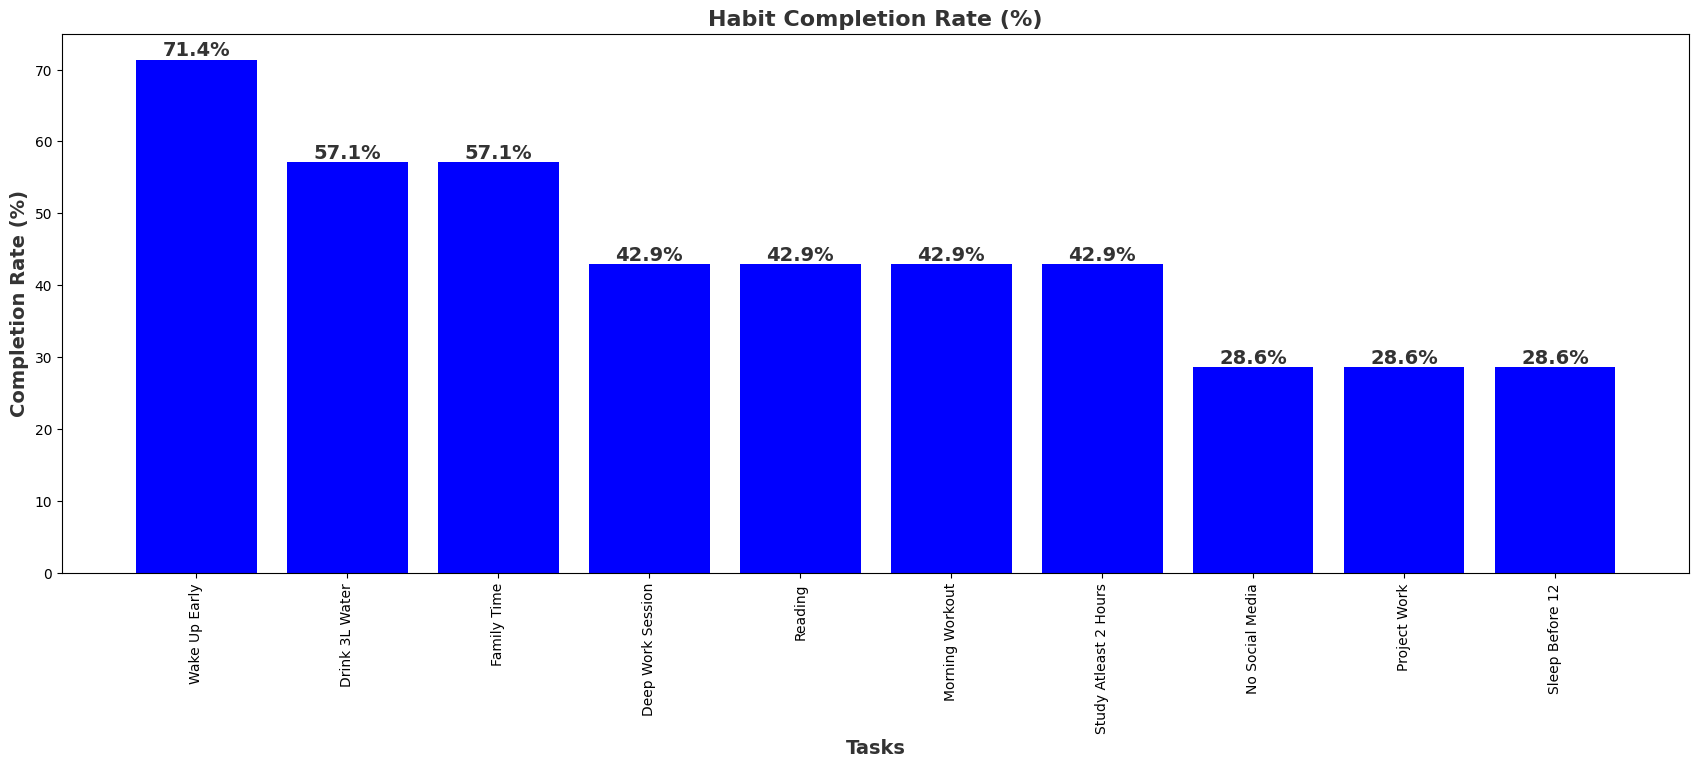

In [53]:
plt.figure(figsize=(21,7))
bars = plt.bar(task_sorted['Task'],task_sorted['Percentage'], color='blue')
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f'{y:.1f}%', 
             ha='center', va='bottom', fontsize=14, fontweight='bold', color='black', alpha=0.8)
plt.ylabel('Completion Rate (%)', fontsize=14, fontweight='bold', color='black', alpha=0.8)
plt.xlabel('Tasks', fontsize=14, fontweight='bold', color='black', alpha=0.8)
plt.title('Habit Completion Rate (%)', fontsize=16, fontweight='bold', color='black', alpha=0.8)
plt.xticks(rotation=90)
plt.show()

#### Creating Pivot Table

In [54]:
ndf['t_date'] = pd.to_datetime(ndf['t_date'])
ndf['day'] = ndf['t_date'].dt.day_name()

tab = ndf.pivot(
    index='task',
    columns='day',
    values='t_status'
)

days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

tab = tab.reindex(columns=days_order)

tab

day,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
task,,,,,,,
Deep Work Session,1,1,0,0,1,0,0
Drink 3L Water,1,1,0,1,1,0,0
Family Time,1,1,0,0,1,0,1
Morning Workout,1,0,0,1,1,0,0
No Social Media,0,1,0,0,1,0,0
Project Work,1,0,0,0,0,1,0
Reading,1,1,0,0,1,0,0
Sleep Before 12,0,0,1,0,1,0,0
Study Atleast 2 Hours,0,0,1,1,0,1,0


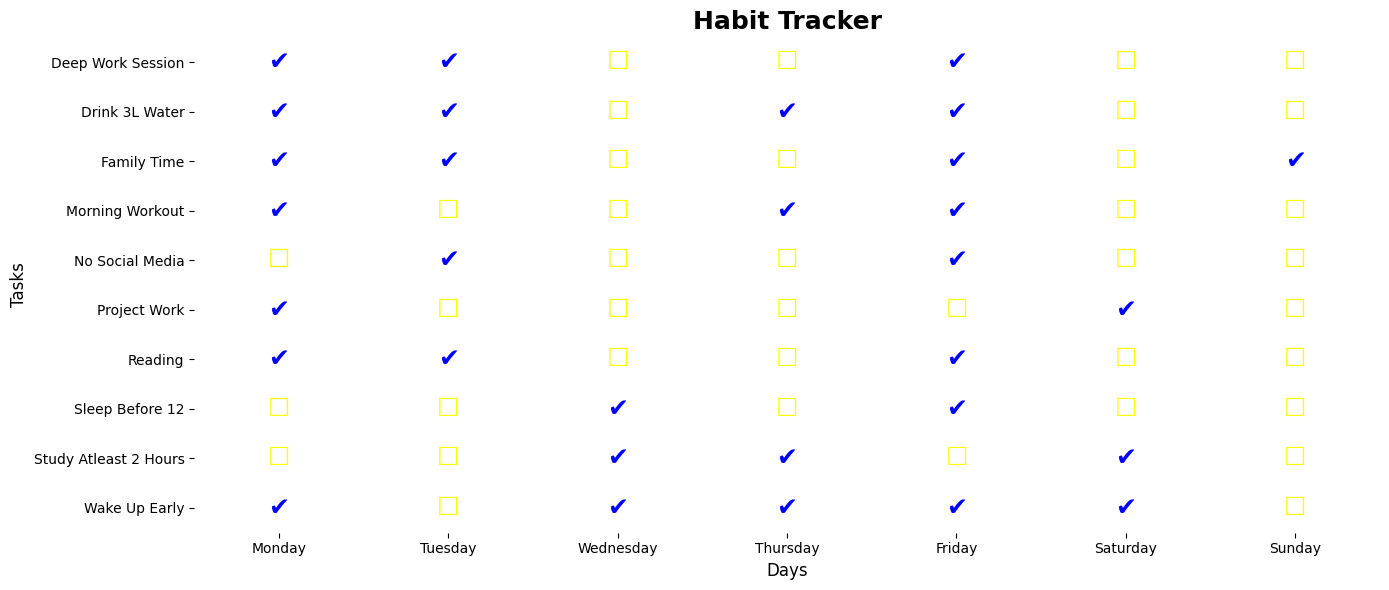

In [55]:
plt.figure(figsize=(14,6))
data = tab

for i in range(data.shape[0]):   
    for j in range(data.shape[1]): 
        
        if data.iloc[i, j] == 1:
            plt.text(j, i, '✔', ha='center', va='center',
                     fontsize=18, color='blue') 
        else:
            plt.text(j, i, '☐', ha='center', va='center',
                     fontsize=18, color='yellow') 

plt.xlim(-0.5, data.shape[1]-0.5)
plt.ylim(data.shape[0]-0.5, -0.5)
plt.xticks(range(data.shape[1]), data.columns, fontsize=10)
plt.yticks(range(data.shape[0]), data.index, fontsize=10)

# plt.grid(color='#ecf0f1', linewidth=1)

for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.gca().set_facecolor('white')

plt.title('Habit Tracker', fontsize=18, fontweight='bold')
plt.xlabel('Days', fontsize=12)
plt.ylabel('Tasks', fontsize=12)

plt.tight_layout()
plt.show()

#### Overall Completion

In [56]:
completed = ndf['t_status'].sum()
total = ndf['t_status'].count()

overall_percentage = (completed/total)*100

print(f"Overall Completion : {overall_percentage:.2f}%")

Overall Completion : 44.29%


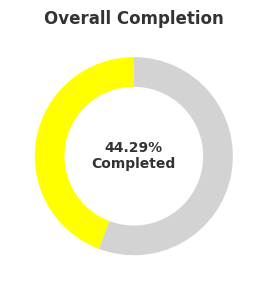

In [57]:
plt.figure(figsize=(6,3))
plt.pie([completed, total - completed],
        startangle=90,
        colors=['yellow', 'lightgrey'])
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.text(0, 0, f'{overall_percentage:.2f}%\nCompleted',
         ha='center', va='center', fontsize=10, fontweight='bold', color='black', alpha=0.8)

plt.title(f'Overall Completion', fontsize=12, fontweight='bold', color='black', alpha=0.8)
plt.tight_layout()
plt.show()

#### All Python(backend/Analysis) id finish for this project, now we export this python file to CSV file then work on POWER BI.

In [58]:
ndf.to_csv('productivity_data.csv', index=False)